In [2]:
from IPython.display import Image, display, Math

#funzione per plottare in LaTex delle matrici
def array_to_latex(array, real = False, array_name = None):
    array = array.real if real else array
    matrix = ''
    for row in array:
        try:
            for number in row:
                matrix += f'{number}&'
        except TypeError:
            matrix += f'{row}&'
        matrix = matrix[:-1] + r'\\'
    if array_name != None:
        display(Math(array_name+r' = \begin{bmatrix}'+matrix+r'\end{bmatrix}'))
    else:
        display(Math(r'\begin{bmatrix}'+matrix+r'\end{bmatrix}'))

In [3]:
import numpy as np
from scipy.integrate import quad
from scipy.linalg import expm
from qutip import *
import numba
from numba import njit, prange
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys
import os

In [27]:
sz = np.array(([[1.0,0.0], [0.0,-1.0]]), dtype=complex); sx = np.array(([[0.0,1.0],[1.0,0.0]]), dtype=complex); sy = np.array(([[0.0,-1j],[1j,0.0]]), dtype=complex) ; sm = np.array(([[0.0, 1.0],[0.0,0.0]]), dtype=complex) ; sp = np.array(([[0.0,0.0],[1.0,0.0]]), dtype=complex)

# ==========================
# Input Parsing from Bash
# ==========================
theta_deg = 0.0  # Default fallback if run manually

# --- Must match the values used in the main simulation script ---
dt = 1.0
N_traj = 10000

dt_str = f"{dt:.2f}".replace(".", "p")
theta_str = f"{theta_deg:.3f}".replace(".", "p")

results_dir = "../Results/Data/"
Output_dir = f"../Results/Plot/Populations/{theta_str}"
os.makedirs(Output_dir, exist_ok=True)

fname = os.path.join(results_dir, f"result_FMO_theta{theta_str}_dt{dt_str}_Ntraj{N_traj}.npz")

try:
    data_QJ = np.load(fname)
    print(f"Data extraction completed successfully for Theta = {theta_deg} deg")
except FileNotFoundError:
    print(f"Error: File {fname} not found. Ensure the simulation for this angle has completed.")
    sys.exit(1)

times = data_QJ['times']
dt_val = float(data_QJ['dt'])
N_site = int(data_QJ['N_site'])
eigenergies = data_QJ['eigenergies']
eigenvectors = data_QJ['eigenvectors']
psi0_exc = data_QJ['psi0_exc']

total_jumps = data_QJ['total_jumps']
jump_counts = data_QJ['jump_counts']            # (n_times, n_traj)

psi_traj_exc = data_QJ['psi_traj']                  # (N_site, n_times, n_traj), exciton basis, complex64
pop_traj_avg = data_QJ['pop_traj_mean']        # (n_times, N_site)
pop_traj_stderr = data_QJ['pop_traj_stderr']

rho_redfield_site = data_QJ['rho_redfield_site']       # (n_times, N_site, N_site)
rho_trace_coll_site = data_QJ['rho_trace_coll_site']  # (n_times, N_site, N_site)
rho_traj_avg_site = data_QJ['rho_traj_avg_site']        # (n_times, N_site, N_site)

n_times, n_traj = jump_counts.shape

# ==========================
# Site-basis single-trajectory populations
# psi_traj is in the exciton basis -> transform to site basis
# ==========================
psi_traj_site = np.einsum('ia,atk->itk', eigenvectors, psi_traj_exc)   # (N_site, n_times, n_traj)
pop_traj_site = np.abs(psi_traj_site) ** 2                          # (N_site, n_times, n_traj)

# ==========================
# Isolated system (no collisions): recomputed on the fly from
# eigenergies, eigenvectors, psi0_exc, times -- no need to store it upfront
# ==========================
phase = np.exp(-1j * np.outer(times, eigenergies))          # (n_times, N)
psi_iso_exc = phase * psi0_exc[None, :]                      # (n_times, N)
psi_iso_site = psi_iso_exc @ eigenvectors.T                  # (n_times, N_site)
pop_iso_site = np.abs(psi_iso_site) ** 2                     # (n_times, N_site)

# ==========================
# Redfield / collisional / MC-avg populations (site basis)
# ==========================
pop_redfield_site = np.real(np.diagonal(rho_redfield_site, axis1=1, axis2=2))       # (n_times, N_site)
pop_trace_coll_site = np.real(np.diagonal(rho_trace_coll_site, axis1=1, axis2=2))  # (n_times, N_site)
pop_traj_avg_site = np.real(np.diagonal(rho_traj_avg_site, axis1=1, axis2=2))              # should ~ pop_traj_avg

# ==========================
# Identify trajectories that experienced at least one jump (theta=0 only meaningful)
# Uses the exact jump record, not a population-threshold heuristic
# ==========================
n_jumps_per_traj_QJ = jump_counts.sum(axis=0)   # (n_traj,)
jump_indices_QJ = np.where(n_jumps_per_traj_QJ > 0)[0]
print(f"Total trajectories: {n_traj}")
print(f"Trajectories with at least one jump: {len(jump_indices_QJ)}")
sample_idx = jump_indices_QJ[0] if len(jump_indices_QJ) > 0 else 0
print(f"Selected sample_idx for single-trajectory plots: {sample_idx}")

# ===========================
# General plot setup
# ===========================
plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 9,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': ':',
    'figure.autolayout': True
})

def save_fig(fig, filename):
    path_png = os.path.join(Output_dir, f"{filename}.png")
    fig.savefig(path_png, dpi=300, bbox_inches='tight')
    print(f"Saved: {path_png}")
    plt.close(fig)

SITE_LABELS = [f"Site {i+1}" for i in range(N_site)]


Data extraction completed successfully for Theta = 0.0 deg
Total trajectories: 10000
Trajectories with at least one jump: 9958
Selected sample_idx for single-trajectory plots: 0


In [28]:
mean_jumps = n_jumps_per_traj_QJ.mean()
var_jumps = n_jumps_per_traj_QJ.var()
print(f"Theta={theta_deg}: mean={mean_jumps:.2f}, var={var_jumps:.2f}, var/mean={var_jumps/mean_jumps:.3f}")


Theta=0.0: mean=5.72, var=5.99, var/mean=1.048


In [29]:
label_traj_QJ = data_QJ['label_traj'] if 'label_traj' in data_QJ else None

In [ ]:
site_idx = 0
for t_check in [1500, 3000, 4500]:   # a piacere, dentro un plateau
    alpha = label_traj_QJ[t_check, sample_idx]
    if alpha >= 0:
        predicted = np.abs(eigenvectors[site_idx, alpha])**2
        observed = pop_traj_site[site_idx, t_check, sample_idx]
        print(f"t={times[t_check]}: alpha={alpha}, predicted={predicted:.5f}, observed={observed:.5f}")

t=1500.0: alpha=5, predicted=0.22456, observed=0.22456
t=3000.0: alpha=2, predicted=0.75378, observed=0.75378
t=4500.0: alpha=2, predicted=0.75378, observed=0.75378


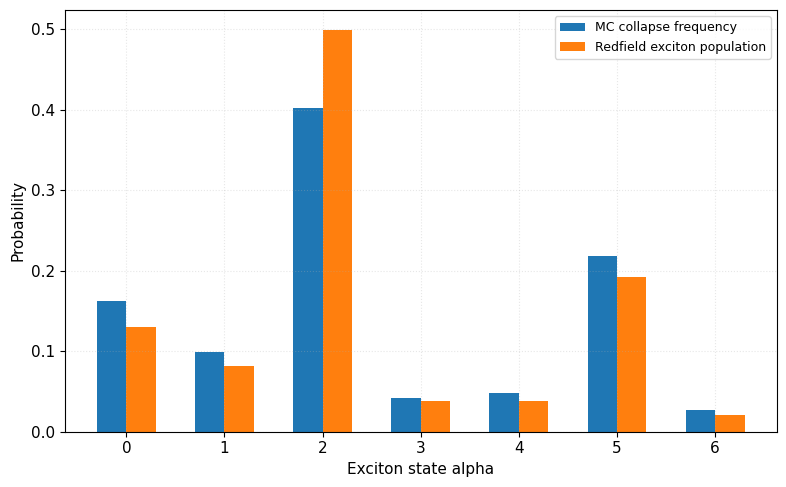

In [17]:
rho_redfield_exc = data_QJ['rho_redfield_exc'] if 'rho_redfield_exc' in data_QJ else None

final_labels = label_traj[-1, :]
final_labels_valid = final_labels[final_labels >= 0]

counts = np.bincount(final_labels_valid, minlength=N_site)
freq = counts / len(final_labels_valid)

# Confronto con la popolazione media Redfield in base eccitonica a t_f
pop_exc_redfield_tf = np.real(np.diagonal(rho_redfield_exc[-1]))

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(np.arange(N_site) - 0.15, freq, width=0.3, label='MC collapse frequency')
ax.bar(np.arange(N_site) + 0.15, pop_exc_redfield_tf, width=0.3, label='Redfield exciton population')
ax.set_xlabel('Exciton state alpha')
ax.set_ylabel('Probability')
ax.legend()

Text(0, 0.5, 'Number of trajectories')

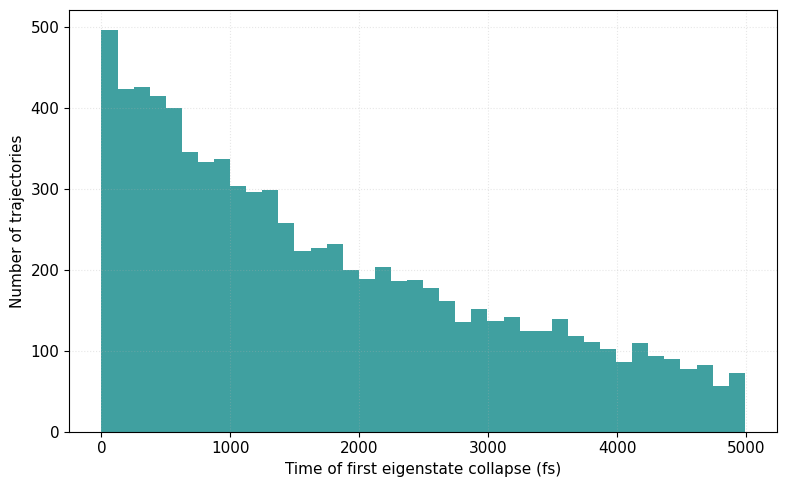

In [18]:
first_jump_time = np.full(n_traj, np.nan)
for k in range(n_traj):
    valid = np.where(label_traj[:, k] >= 0)[0]
    if len(valid) > 0:
        first_jump_time[k] = times[valid[0]]

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(first_jump_time[~np.isnan(first_jump_time)], bins=40, color='teal', alpha=0.75)
ax.set_xlabel('Time of first eigenstate collapse (fs)')
ax.set_ylabel('Number of trajectories')

<>:34: SyntaxWarning: invalid escape sequence '\T'
<>:34: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_22236/2108588595.py:34: SyntaxWarning: invalid escape sequence '\T'
  ax.set_title(f'Decoherence Time / Survival Probability ($\Theta = 0^\circ$)')


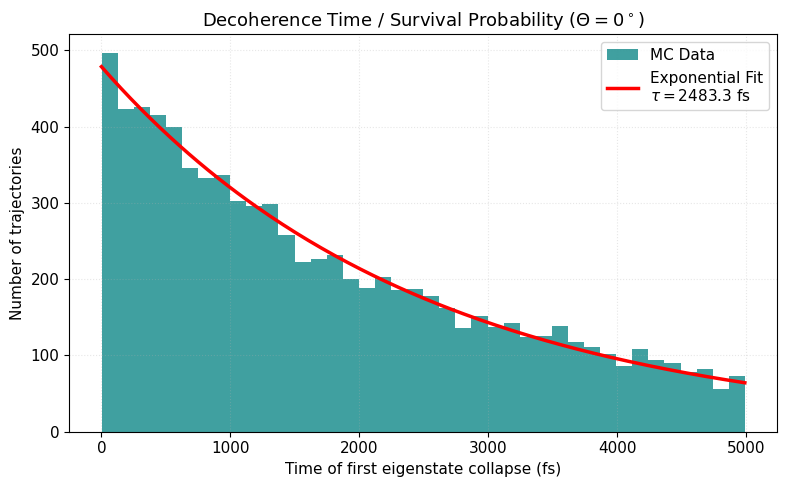

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Assicuriamoci di filtrare i NaN
valid_jump_times = first_jump_time[~np.isnan(first_jump_time)]

# 2. Definiamo la funzione di decadimento esponenziale da fittare
def exp_decay(t, A, tau):
    return A * np.exp(-t / tau)

fig, ax = plt.subplots(figsize=(8, 5))

# 3. Disegniamo l'istogramma e salviamo i conteggi (counts) e i bordi dei bin (bins)
counts, bins, _ = ax.hist(valid_jump_times, bins=40, color='teal', alpha=0.75, label='MC Data')

# 4. Calcoliamo i centri dei bin per fare il fit sulle "punte" delle barre
bin_centers = (bins[:-1] + bins[1:]) / 2

# 5. Facciamo il fit (p0 è un "guess" iniziale per i parametri A e tau)
guess_A = np.max(counts)
guess_tau = 1000.0  # Guess ragionevole guardando il grafico
popt, _ = curve_fit(exp_decay, bin_centers, counts, p0=[guess_A, guess_tau])

A_fit, tau_fit = popt

# 6. Disegniamo la curva di fit sopra l'istogramma
t_smooth = np.linspace(0, np.max(valid_jump_times), 200)
ax.plot(t_smooth, exp_decay(t_smooth, A_fit, tau_fit), color='red', linewidth=2.5, 
        label=f'Exponential Fit\n$\\tau = {tau_fit:.1f}$ fs')

ax.set_xlabel('Time of first eigenstate collapse (fs)')
ax.set_ylabel('Number of trajectories')
ax.set_title(f'Decoherence Time / Survival Probability ($\Theta = 0^\circ$)')
ax.legend(fontsize=11)

plt.show()

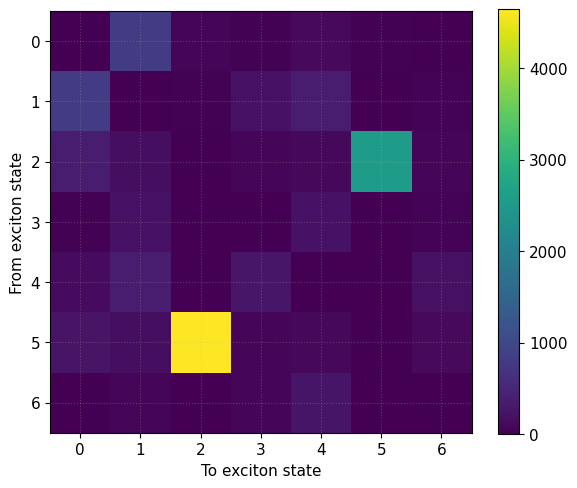

In [19]:
transition_counts = np.zeros((N_site, N_site), dtype=int)
for k in range(n_traj):
    labels_k = label_traj[:, k]
    changes = np.where(np.diff(labels_k) != 0)[0]
    for idx in changes:
        prev, curr = labels_k[idx], labels_k[idx+1]
        if prev >= 0 and curr >= 0:
            transition_counts[prev, curr] += 1

# Visualizza come heatmap
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(transition_counts, cmap='viridis')
ax.set_xlabel('To exciton state')
ax.set_ylabel('From exciton state')
plt.colorbar(im, ax=ax)

In [35]:

sz = np.array(([[1.0,0.0], [0.0,-1.0]]), dtype=complex); sx = np.array(([[0.0,1.0],[1.0,0.0]]), dtype=complex); sy = np.array(([[0.0,-1j],[1j,0.0]]), dtype=complex) ; sm = np.array(([[0.0, 1.0],[0.0,0.0]]), dtype=complex) ; sp = np.array(([[0.0,0.0],[1.0,0.0]]), dtype=complex)

# ==========================
# Input Parsing from Bash
# ==========================
theta_deg = 90.0  # Default fallback if run manually

# --- Must match the values used in the main simulation script ---
dt = 1.0
N_traj = 10000

dt_str = f"{dt:.2f}".replace(".", "p")
theta_str = f"{theta_deg:.3f}".replace(".", "p")

results_dir = "../Results/Data/"
Output_dir = f"../Results/Plot/Populations/{theta_str}"
os.makedirs(Output_dir, exist_ok=True)

fname = os.path.join(results_dir, f"result_FMO_theta{theta_str}_dt{dt_str}_Ntraj{N_traj}.npz")

try:
    data_SD = np.load(fname)
    print(f"Data extraction completed successfully for Theta = {theta_deg} deg")
except FileNotFoundError:
    print(f"Error: File {fname} not found. Ensure the simulation for this angle has completed.")
    sys.exit(1)

times = data_SD['times']
dt_val = float(data_SD['dt'])
N_site = int(data_SD['N_site'])
eigenergies = data_SD['eigenergies']
eigenvectors = data_SD['eigenvectors']
psi0_exc = data_SD['psi0_exc']

total_jumps_SD = data_SD['total_jumps']
jump_counts_SD = data_SD['jump_counts']            # (n_times, n_traj)

psi_traj_exc_SD = data_SD['psi_traj']                  # (N_site, n_times, n_traj), exciton basis, complex64
pop_traj_avg_SD = data_SD['pop_traj_mean']        # (n_times, N_site)
pop_traj_stderr_SD = data_SD['pop_traj_stderr']

rho_redfield_site_SD = data_SD['rho_redfield_site']       # (n_times, N_site, N_site)
rho_trace_coll_site_SD = data_SD['rho_trace_coll_site']  # (n_times, N_site, N_site)
rho_traj_avg_site_SD = data_SD['rho_traj_avg_site']        # (n_times, N_site, N_site)

n_times, n_traj = jump_counts_SD.shape

# ==========================
# Site-basis single-trajectory populations
# psi_traj is in the exciton basis -> transform to site basis
# ==========================
psi_traj_site_SD = np.einsum('ia,atk->itk', eigenvectors, psi_traj_exc_SD)   # (N_site, n_times, n_traj)
pop_traj_site_SD = np.abs(psi_traj_site_SD) ** 2                          # (N_site, n_times, n_traj)

# ==========================
# Isolated system (no collisions): recomputed on the fly from
# eigenergies, eigenvectors, psi0_exc, times -- no need to store it upfront
# ==========================
phase_SD = np.exp(-1j * np.outer(times, eigenergies))          # (n_times, N)
psi_iso_exc_SD = phase_SD * psi0_exc[None, :]                      # (n_times, N)
psi_iso_site = psi_iso_exc_SD @ eigenvectors.T                  # (n_times, N_site)
pop_iso_site_SD = np.abs(psi_iso_site) ** 2                     # (n_times, N_site)

# ==========================
# Redfield / collisional / MC-avg populations (site basis)
# ==========================
pop_redfield_site_SD = np.real(np.diagonal(rho_redfield_site, axis1=1, axis2=2))       # (n_times, N_site)
pop_trace_coll_site_SD = np.real(np.diagonal(rho_trace_coll_site, axis1=1, axis2=2))  # (n_times, N_site)
pop_traj_avg_site_SD = np.real(np.diagonal(rho_traj_avg_site, axis1=1, axis2=2))              # should ~ pop_traj_avg

# ==========================
# Identify trajectories that experienced at least one jump (theta=0 only meaningful)
# Uses the exact jump record, not a population-threshold heuristic
# ==========================
n_jumps_per_traj_SD = jump_counts.sum(axis=0)   # (n_traj,)
jump_indices_SD = np.where(n_jumps_per_traj_SD > 0)[0]
print(f"Total trajectories: {n_traj}")
print(f"Trajectories with at least one jump: {len(jump_indices_SD)}")
sample_idx = jump_indices_SD[0] if len(jump_indices_SD) > 0 else 0
print(f"Selected sample_idx for single-trajectory plots: {sample_idx}")

# ===========================
# General plot setup
# ===========================
plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 9,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': ':',
    'figure.autolayout': True
})

def save_fig(fig, filename):
    path_png = os.path.join(Output_dir, f"{filename}.png")
    fig.savefig(path_png, dpi=300, bbox_inches='tight')
    print(f"Saved: {path_png}")
    plt.close(fig)

SITE_LABELS = [f"Site {i+1}" for i in range(N_site)]


Data extraction completed successfully for Theta = 90.0 deg
Total trajectories: 10000
Trajectories with at least one jump: 10000
Selected sample_idx for single-trajectory plots: 0


In [ ]:
mean_jumps_SD = n_jumps_per_traj_SD.mean()
var_jumps_SD = n_jumps_per_traj_SD.var()
print(f"Theta={theta_deg}: mean={mean_jumps_SD:.2f}, var={var_jumps_SD:.2f}, var/mean={var_jumps_SD/mean_jumps_SD:.3f}")



Theta=90.0: mean=122476.71, var=60955.24, var/mean=0.498


In [41]:
# Calcola E_i - E_j
delta_E = np.subtract.outer(eigenergies, eigenergies)
array_to_latex(delta_E)
massimo = np.max(delta_E)
massimo


<IPython.core.display.Math object>

np.float64(0.09364916124810055)

<>:24: SyntaxWarning: invalid escape sequence '\T'
<>:24: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_22236/856399261.py:24: SyntaxWarning: invalid escape sequence '\T'
  ax1.set_title("Diffusive Dynamics ($\Theta = 90^\circ$): Continuous Sloshing")


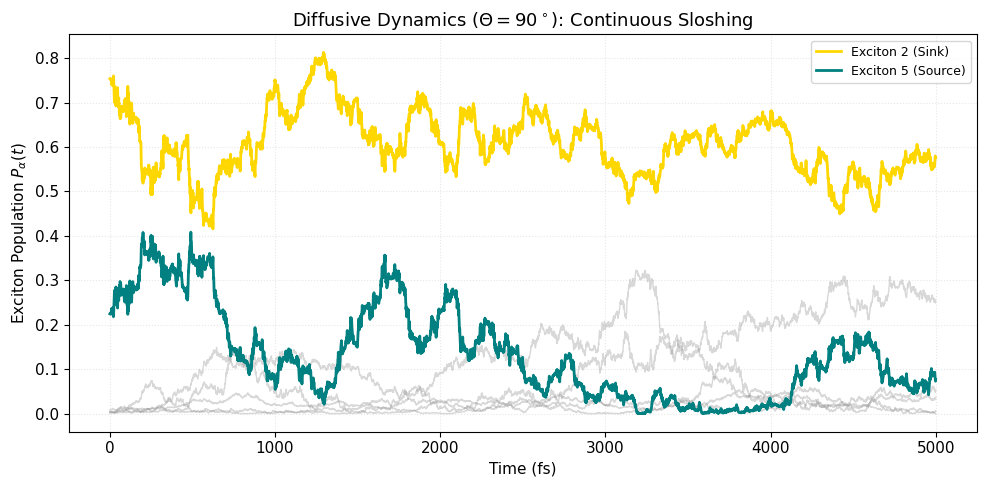

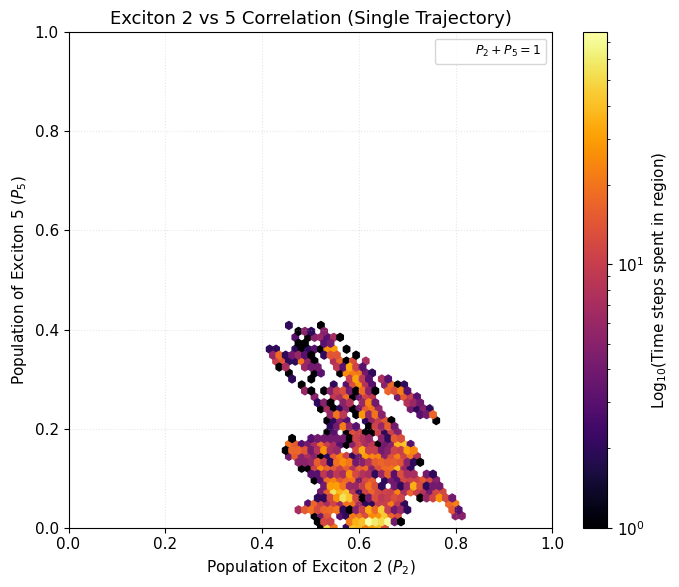

In [36]:
# 2. Selezioniamo una singola traiettoria (es. la primissima)
sample_idx = 0
psi_single_SD = psi_traj_exc_SD[:, :, sample_idx]

# 3. Calcoliamo le popolazioni eccitoniche continue P_alpha(t) = |c_alpha(t)|^2
pop_exc_single_SD = np.abs(psi_single_SD)**2  # (7, n_times)

# ====================================================================
# PLOT 1: Popolazioni Eccitoniche Continue nel Tempo
# ====================================================================
fig1, ax1 = plt.subplots(figsize=(10, 5))

# Plottiamo in grigio chiaro/trasparente tutti gli stati "minori"
for alpha in range(7):
    if alpha not in [2, 5]:
        ax1.plot(times, pop_exc_single_SD[alpha, :], color='gray', alpha=0.3, linewidth=1)

# Mettiamo in forte risalto l'autostrada (Stati 2 e 5)
ax1.plot(times, pop_exc_single_SD[2, :], color='gold', linewidth=2, label='Exciton 2 (Sink)')
ax1.plot(times, pop_exc_single_SD[5, :], color='teal', linewidth=2, label='Exciton 5 (Source)')

ax1.set_xlabel("Time (fs)")
ax1.set_ylabel("Exciton Population $P_\\alpha(t)$")
ax1.set_title("Diffusive Dynamics ($\Theta = 90^\circ$): Continuous Sloshing")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ====================================================================
# PLOT 2: Mappa di Correlazione (State-Space Density)
# ====================================================================
fig2, ax2 = plt.subplots(figsize=(7, 6))

P2 = pop_exc_single_SD[2, :]
P5 = pop_exc_single_SD[5, :]

# Creiamo un istogramma 2D esagonale (hexbin) per vedere dove la traiettoria spende più tempo
hb = ax2.hexbin(P2, P5, gridsize=30, cmap='inferno', bins='log')
cb = plt.colorbar(hb, ax=ax2)
cb.set_label('Log$_{10}$(Time steps spent in region)')

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_xlabel("Population of Exciton 2 ($P_2$)")
ax2.set_ylabel("Population of Exciton 5 ($P_5$)")
ax2.set_title("Exciton 2 vs 5 Correlation (Single Trajectory)")

# Aggiungiamo una riga guida anti-correlazione ideale (P2 + P5 = 1)
ax2.plot([0, 1], [1, 0], color='white', linestyle='--', alpha=0.5, label='$P_2 + P_5 = 1$')
ax2.legend()

plt.tight_layout()
plt.show()

In [44]:
import pandas as pd
import numpy as np


def compute_w_alphabeta(S_exc):
    """
    Computes the geometric coupling factor w_{alpha,beta} = sum_i |<alpha|S_i|beta>|^2.
    Returns array of shape (N_alpha, N_beta).
    """
    N = S_exc.shape[1]
    w = np.zeros((N, N))
    for a in range(N):
        for b in range(N):
            w[a, b] = np.sum(np.abs(S_exc[:, a, b])**2)
    return w


def bose_factor_stable(x):
    """
    Numerically stable computation of 1/(1 - exp(-x)) for any real x
    (avoids overflow for large |x|).
    """
    scalar_input = np.isscalar(x) or np.asarray(x).ndim == 0
    x = np.atleast_1d(np.asarray(x, dtype=float))
    out = np.empty_like(x)

    pos = x > 0
    out[pos] = 1.0 / (1.0 - np.exp(-x[pos]))

    neg = ~pos
    ex = np.exp(x[neg])
    out[neg] = ex / (ex - 1.0)

    return out[0] if scalar_input else out


def C_drude_lorentz(omega, lam, Omega, beta, omega_tol=1e-10):
    """
    Drude-Lorentz spectral function C(omega) = 4*lam*omega*Omega/(omega^2+Omega^2) * 1/(1-exp(-omega*beta)).
    Handles the omega -> 0 limit analytically, numerically stable for large |omega|.
    """
    scalar_input = np.isscalar(omega) or np.asarray(omega).ndim == 0
    omega = np.atleast_1d(np.asarray(omega, dtype=float))
    out = np.empty_like(omega)

    small = np.abs(omega) < omega_tol
    out[small] = 4.0 * lam / (Omega * beta)

    w = omega[~small]
    if w.size > 0:
        lorentz = 4.0 * lam * w * Omega / (w**2 + Omega**2)
        out[~small] = lorentz * bose_factor_stable(w * beta)

    return out[0] if scalar_input else out


# ====================
# Physical parameters
# ====================

c_light_cm_fs = 2.99792458e-5
cm1_to_radfs = 2.0 * np.pi * c_light_cm_fs
KB_cm1_per_K = 0.695034800

T_kelvin = 347.0
lam_cm1 = 35.0
# Omega_cm1 = 106.1

lam = lam_cm1 * cm1_to_radfs
# Omega = Omega_cm1 * cm1_to_radfs
Omega = 1.0   # already in fs^-1 units
beta = 1.0 / (KB_cm1_per_K * T_kelvin * cm1_to_radfs)

C_func = lambda w: C_drude_lorentz(w, lam, Omega, beta)

H_exc_cm1 = np.array([
    [200,  -96,    5,  -4.4,   4.7, -12.6,  -6.2],
    [-96,  320, 33.1,   6.8,   4.5,   7.4,  -0.3],
    [5,   33.1,    0, -51.1,   0.8,  -8.4,   7.6],
    [-4.4,  6.8,-51.1,   110, -76.6, -14.2,   -67],
    [4.7,   4.5,  0.8, -76.6,   270,  78.3,  -0.1],
    [-12.6, 7.4, -8.4, -14.2,  78.3,   420,  38.3],
    [-6.2, -0.3,  7.6,   -67,  -0.1,  38.3,   230]
], dtype=complex)

N_site = H_exc_cm1.shape[0]
H_exc = H_exc_cm1 * cm1_to_radfs

eigenergies, eigenvectors = np.linalg.eigh(H_exc)

S_site = np.zeros((N_site, N_site, N_site), dtype=complex)
for i in range(N_site):
    S_site[i, i, i] = 1.0

S_exc = np.zeros_like(S_site)
for i in range(N_site):
    S_exc[i] = eigenvectors.conj().T @ S_site[i] @ eigenvectors

s_weights = np.array([np.real(np.diag(S_exc[i])) for i in range(N_site)])
w_ab = compute_w_alphabeta(S_exc)

c_light_cm_fs = 2.99792458e-5
cm1_to_radfs = 2.0 * np.pi * c_light_cm_fs
KB_cm1_per_K = 0.695034800

N_site = H_exc_cm1.shape[0]
H_exc = H_exc_cm1 * cm1_to_radfs

eigenergies, eigenvectors = np.linalg.eigh(H_exc)

# 1. Calcolo la matrice delle differenze di energia (omega_ab = E_beta - E_alpha)
# L'indice di riga è alpha (stato di partenza), la colonna è beta (stato di arrivo)
omega_matrix = eigenergies - eigenergies[:, np.newaxis]

# 2. Valuto la funzione spettrale C(omega) su tutta la matrice
# La tua C_func è già vettorizzata, quindi digerisce l'intera matrice in un colpo solo!
C_matrix = np.real(C_func(omega_matrix))

# 3. La matrice w_ab ce l'hai già calcolata dal tuo codice
# Calcolo i tassi di transizione totali moltiplicando elemento per elemento:
gamma_matrix = C_matrix * w_ab

# ==========================================
# STAMPA DELLE TABELLE CON PANDAS
# ==========================================
# Impostiamo le etichette per righe e colonne da 0 a 6
labels = [f"{i}" for i in range(7)]

df_C = pd.DataFrame(C_matrix, index=labels, columns=labels)
df_w = pd.DataFrame(w_ab, index=labels, columns=labels)
df_gamma = pd.DataFrame(gamma_matrix, index=labels, columns=labels)

print("--- Matrice C(omega) [Fattore Termico e Risonanza] ---")
display(df_C.style.format("{:.4f}").background_gradient(cmap='Blues'))

print("\n--- Matrice w_ab [Fattore Geometrico di Sovrapposizione] ---")
display(df_w.style.format("{:.4f}").background_gradient(cmap='Greens'))

print("\n--- Matrice Gamma (Tassi di Transizione Totali) ---")
display(df_gamma.style.format("{:.4f}").background_gradient(cmap='Purples'))

# ==========================================
# CONFRONTO DIRETTO: 5->2 vs 6->0
# ==========================================
print("\n" + "="*50)
print("ANALISI FISICA DELLE TRANSIZIONI")
print("="*50)

# Transizione 5 -> 2 (Riga 5, Colonna 2)
c_52 = C_matrix[5, 2]
w_52 = w_ab[5, 2]
gamma_52 = gamma_matrix[5, 2]

# Transizione 6 -> 0 (Riga 6, Colonna 0)
c_60 = C_matrix[6, 0]
w_60 = w_ab[6, 0]
gamma_60 = gamma_matrix[6, 0]

print(f"Tratto 5 -> 2 (L'autostrada osservata):")
print(f"  C(omega) : {c_52:.5f}")
print(f"  w_ab     : {w_52:.5f}")
print(f"  GAMMA    : {gamma_52:.5f} <-- Probabilità Dominante")

print(f"\nTratto 6 -> 0 (Il salto energetico massimo):")
print(f"  C(omega) : {c_60:.5f}")
print(f"  w_ab     : {w_60:.5f}")
print(f"  GAMMA    : {gamma_60:.5f} <-- Completamente bloccata!")

--- Matrice C(omega) [Fattore Termico e Risonanza] ---


,0,1,2,3,4,5,6
0,0.0012,0.0015,0.0017,0.0020,0.0021,0.0025,0.0028
1,0.0010,0.0012,0.0014,0.0017,0.0017,0.0021,0.0024
2,0.0008,0.0010,0.0012,0.0015,0.0015,0.0018,0.0022
3,0.0006,0.0008,0.0010,0.0012,0.0013,0.0015,0.0018
4,0.0006,0.0008,0.0009,0.0011,0.0012,0.0015,0.0018
5,0.0005,0.0006,0.0007,0.0009,0.0010,0.0012,0.0014
6,0.0004,0.0005,0.0006,0.0007,0.0008,0.0010,0.0012



--- Matrice w_ab [Fattore Geometrico di Sovrapposizione] ---


,0,1,2,3,4,5,6
0,0.6435,0.2457,0.0198,0.0137,0.0569,0.0136,0.0069
1,0.2457,0.3711,0.0125,0.1358,0.1841,0.0088,0.0421
2,0.0198,0.0125,0.6137,0.0060,0.0082,0.3296,0.0102
3,0.0137,0.1358,0.0060,0.5648,0.2052,0.0049,0.0697
4,0.0569,0.1841,0.0082,0.2052,0.2917,0.0091,0.2449
5,0.0136,0.0088,0.3296,0.0049,0.0091,0.6199,0.0143
6,0.0069,0.0421,0.0102,0.0697,0.2449,0.0143,0.6120



--- Matrice Gamma (Tassi di Transizione Totali) ---


,0,1,2,3,4,5,6
0,0.0008,0.0004,0.0000,0.0000,0.0001,0.0000,0.0000
1,0.0002,0.0004,0.0000,0.0002,0.0003,0.0000,0.0001
2,0.0000,0.0000,0.0007,0.0000,0.0000,0.0006,0.0000
3,0.0000,0.0001,0.0000,0.0007,0.0003,0.0000,0.0001
4,0.0000,0.0001,0.0000,0.0002,0.0003,0.0000,0.0004
5,0.0000,0.0000,0.0002,0.0000,0.0000,0.0007,0.0000
6,0.0000,0.0000,0.0000,0.0001,0.0002,0.0000,0.0007



ANALISI FISICA DELLE TRANSIZIONI
Tratto 5 -> 2 (L'autostrada osservata):
  C(omega) : 0.00072
  w_ab     : 0.32960
  GAMMA    : 0.00024 <-- Probabilità Dominante

Tratto 6 -> 0 (Il salto energetico massimo):
  C(omega) : 0.00036
  w_ab     : 0.00688
  GAMMA    : 0.00000 <-- Completamente bloccata!
